In [18]:
from FastBEMT.Propeller import Propeller
from FastBEMT.JobParameters import LowFidelityParameters
from FastBEMT.DataLoader import *
import pickle
import numpy as np
import torch
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['science', 'no-latex'])

In [ ]:
blade_dict = load_propeller_dict('10x7E')

In [20]:
params = LowFidelityParameters(
    rpm=7000,
    a_inf=343,
    rho=1.225,
    mu=1.81e-5,
    n_blades=blade_dict['n_blades'],
    p_ref=2e-5,
    revolutions=5,
    num_obs_times_per_rev=100,
    device='cuda'
)

In [21]:
nx, ny = 26, 26
size = 5

In [22]:
x_range = np.linspace(-size, size, nx)
y_range = np.linspace(-size, size, ny)
X, Y = np.meshgrid(x_range, y_range)
Z = np.zeros_like(X) 

r_observers = np.stack([X.flatten(), Y.flatten(), Z.flatten()], axis=1)

propeller = Propeller(
    propeller_geometry=blade_dict,
    params=params,
)

propeller.run_bemt(v_inf=0.0)

In [23]:
propeller.run_aeroacoustics(observer_positions=r_observers,
        lt=1,
        i=1e-3,
        alpha_stall=12.5,
        keep_bpm_components=False)

[CUDA TIMING] TorchCompactAcousticSourceArray.__init__: 1.890 ms
[CUDA TIMING] BPM.__init__: 1.012 ms
[CUDA TIMING] get_observer_times: 6.173 ms
[CUDA TIMING] calculate_f1a_pressure: 204.338 ms
[CUDA TIMING] combine_sources (F1A): 50.844 ms
[CUDA TIMING] _perform_spectral_analysis_torch: 2.494 ms
[CUDA TIMING] BPM.run_forward_bpm: 1702.995 ms
[CUDA TIMING] combine_sources_bpm: 0.405 ms


In [24]:
propeller.postprocess()

In [25]:
propeller.third_octave_total_oaspl = propeller.third_octave_total_oaspl.reshape(ny, nx)

In [26]:
from FastBEMT.Stress import BladeStressCalculator

stress_calc = BladeStressCalculator(propeller=propeller)

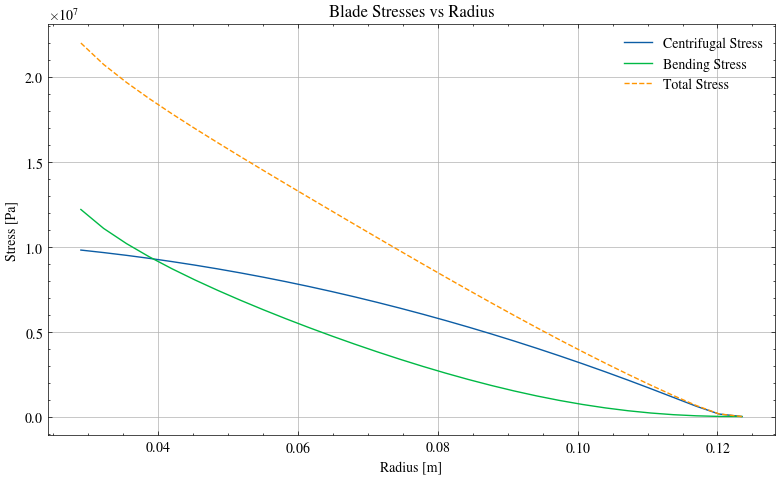

(array([9805417.16025227, 9657221.97837096, 9494908.99946431,
        9317897.0008328 , 9126021.10357028, 8919210.62455409,
        8697431.04535123, 8460665.16771115, 8208905.24587907,
        7942149.17407539, 7660398.444695  , 7363656.97338452,
        7051930.38567246, 6725225.56573719, 6383550.36191102,
        6026913.38992736, 5655323.89931093, 5268791.68181445,
        4867327.00865946, 4450940.58861514, 4019643.54796208,
        3573447.4908163 , 3112365.15300719, 2636415.51774635,
        2145659.94162937, 1640437.05038551, 1122777.96162676,
         604313.40142948,  146301.0349731 ,       0.        ]),
 array([1.21956874e+07, 1.10793849e+07, 1.01872486e+07, 9.40812748e+06,
        8.70212710e+06, 8.04811404e+06, 7.43367117e+06, 6.85000584e+06,
        6.29203511e+06, 5.75684420e+06, 5.24235853e+06, 4.74679166e+06,
        4.26977976e+06, 3.81145666e+06, 3.37244237e+06, 2.95367024e+06,
        2.55638415e+06, 2.18200085e+06, 1.83213379e+06, 1.50844986e+06,
        1.21270645

In [27]:
stress_calc.blade_stress_report(material_rho=2700, show = True)

In [28]:
def load_data(filepath, channel):
    with open(filepath, 'rb') as f:
        data = pickle.load(f)
    t = data['sound']['channels'][str(channel)]['time']
    p = data['sound']['channels'][str(channel)]['pressure']
    fs = 1.0 / np.mean(np.diff(t))
    return t, p, fs


def extract_propeller_noise(p_total, p_motor, fs, nperseg=1024, alpha=1.0, beta=0.1):
    f, t, Zxx_total = scipy.signal.stft(p_total, fs=fs, nperseg=nperseg)
    _, _, Zxx_motor = scipy.signal.stft(p_motor, fs=fs, nperseg=nperseg)

    mag_total = np.abs(Zxx_total)
    phase_total = np.angle(Zxx_total)
    mag_motor_avg = np.mean(np.abs(Zxx_motor), axis=1, keepdims=True)

    mag_prop = np.maximum(mag_total - (alpha * mag_motor_avg), beta * mag_motor_avg)
    
    Zxx_prop = mag_prop * np.exp(1j * phase_total)
    t_final, p_prop_only = scipy.signal.istft(Zxx_prop, fs=fs)
    
    return t_final, p_prop_only

In [29]:
def calc_oaspl_np(spl_array, freqs, weighted=False):
    """Calculates OSPL or A-weighted OASPL."""
    valid_mask = np.isfinite(spl_array)
    spl = spl_array[valid_mask]
    f = freqs[valid_mask]
    
    if len(spl) == 0: return 0
    
    if weighted:
        a_offsets = get_a_weighting_np(f)
        spl = spl + a_offsets
        
    return 10 * np.log10(np.sum(10**(spl / 10)))

In [30]:
def get_a_weighting_np(f):
    """Calculate A-weighting offset in dB for a given frequency f."""
    ra = lambda f: (12194**2 * f**4) / (
        (f**2 + 20.6**2) * np.sqrt((f**2 + 107.7**2) * (f**2 + 737.9**2)) * (f**2 + 12194**2)
    )
    return 20 * np.log10(ra(f)) - 20 * np.log10(ra(1000))

In [31]:
# import pyfar as pf
# import scipy
# res = []

# f_low = propeller.third_octave_freqs.cpu().numpy() / (2 ** (1 / 6))
# f_high = propeller.third_octave_freqs.cpu().numpy() * (2 ** (1 / 6))

# for channel in range(1,11):
#     print('channel')
#     t_total, p_total, fs_total = load_data('../Datasets/Measurements/10x7e_2024-11-28-13-14-55_RPM_7000.pkl', channel=channel)
#     t_motor, p_motor, fs_motor = load_data('../Datasets/Background/Background_2024-11-28-12-56-35_RPM_7000.pkl', channel=channel)
#     t_final, p_prop_only = extract_propeller_noise(p_total, p_motor, fs_total)
#     fs = 1 / (t_final[1] - t_final[0])
#     signal = pf.Signal(p_prop_only, fs, fft_norm='rms')
#     clean_frequencies = signal.frequencies[np.newaxis, ...]
#     clean_spl = pf.dsp.decibel(signal, domain='freq', log_reference=2e-5).T

#     mask = (clean_frequencies >= f_low[..., np.newaxis]) & \
#         (clean_frequencies <= f_high[..., np.newaxis])

#     # 4. Convert SPL to Power
#     p_raw = 10 ** (clean_spl / 10)
#     p_band = mask @ p_raw
#     clean_spl_3oct = 10 * np.log10(p_band)
#     clean_spl_3oct[p_band == 0] = -np.inf
#     clean_ospl_exp = calc_oaspl_np(clean_spl_3oct.squeeze(), propeller.third_octave_freqs.cpu().numpy(), weighted=True)
#     res.append(clean_ospl_exp)


In [32]:
r_observers = 1.88 * np.array([
    [0.050,  0.000, -0.999], # Position 1
    [0.150, -0.856,  0.494], # Position 2
    [0.250,  0.839,  0.484], # Position 3
    [0.350,  0.811, -0.468], # Position 4
    [0.450, -0.773, -0.447], # Position 5
    [0.550,  0.000,  0.835], # Position 6
    [0.650,  0.658,  0.380], # Position 7
    [0.750,  0.000, -0.661], # Position 8
    [0.850, -0.456,  0.263], # Position 9
    [0.950,  0.000,  0.312]  # Position 10
])

X_obs = r_observers[:, 0]
Y_obs = (r_observers[:, 1]**2 + r_observers[:, 2]**2)**0.5

ValueError: lower_level and upper_level cannot be NaN

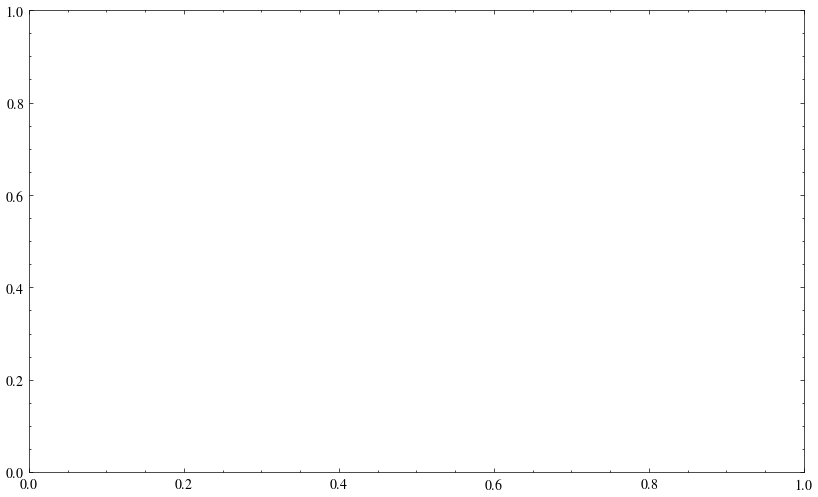

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
# fig, ax = plt.subplots(figsize=(4.5, 2))

vmin = np.floor(propeller.third_octave_total_oaspl.min() / 10) * 10
vmax = np.ceil(propeller.third_octave_total_oaspl.max() / 10) * 10
# vmin = 60
# vmax = 65

smooth_levels = np.linspace(vmin, vmax, 1000)
cf = ax.contourf(Y, X, propeller.third_octave_total_oaspl, levels=smooth_levels, cmap='magma')
im = ax.pcolormesh(Y, X, propeller.third_octave_total_oaspl, cmap='magma', 
                   vmin=vmin, vmax=vmax, shading='gouraud', zorder=1)
# cbar = fig.colorbar(im, ax=ax, shrink=1, aspect=10, pad=0.05, ticks=np.arange(vmin, vmax + 1, 1))

cbar = fig.colorbar(im, ax=ax, shrink=1, aspect=10, pad=0.05, ticks=np.arange(vmin, vmax + 10, 10))

cbar.set_label('OASPL [dB(A)]', fontsize=12)
cbar.ax.tick_params(labelsize=10)

angles = np.linspace(-np.pi,np.pi,100)
r=10*propeller.geometry['tip_radius']
ax.plot(r*np.cos(angles), r*np.sin(angles), '--', c='g', linewidth=1)

line_levels = [65]
label_coords = [(2.0, 2.0), (2.0, 1.0), (2.0, 3.0), (2.0, 3.0), (2.0, 3.0), (2.0, 3.0)] 

for level, coord in zip(line_levels, label_coords):
    cntr = ax.contour(Y, X, propeller.third_octave_total_oaspl, levels=[level], colors='white', 
                      linewidths=0.8, alpha=0.5)
    ax.clabel(cntr, inline=True, fontsize=12, fmt='%1.0f dB', manual=[coord])

# ax.plot(0, 0, 'ro', markersize=5, label='Propeller Center', markeredgecolor='white')

# sc = plt.scatter(Y_obs, X_obs, c=res, cmap='viridis', s=50)

# Add labels (Index and Value) to each point
# for i, val in enumerate(res):
#     # Format: "Index: Value"
#     label_text = f'${i+1}: {val:.2f}$' 
    
#     plt.annotate(
#         label_text, 
#         (Y_obs[i], X_obs[i]), 
#         textcoords="offset points", 
#         xytext=(5, 5), 
#         fontsize=9,
#         alpha=0.9,
#         fontweight='bold'
#     )

ax.set_xlabel('r [m]', fontsize=12)
ax.set_ylabel('Z [m]', fontsize=12)

# ax.set_aspect(aspect=0.5)
ax.grid(True, alpha=0.15, color='white')
# plt.legend(fontsize=12, frameon=True, edgecolor='white', loc='upper left')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.savefig('../Figures/acoustic_map.pdf', dpi=200)
plt.show()

In [ ]:
from shapely.geometry import Polygon, box

target_level = 70.0
weight_below = 5.0  # Weight for the area where X < 0
weight_above = 1.0  # Weight for the area where X >= 0

specific_contour = ax.contour(Y, X, propeller.third_octave_total_oaspl, levels=[target_level])
bottom_half_box = box(-size, -size, size, 0.0) 
top_half_box = box(-size, 0.0, size, size)

area_above = 0.0
area_below = 0.0

for path in specific_contour.get_paths():
    vertices = path.vertices
    if len(vertices) > 3:
        poly = Polygon(vertices)
        
        poly_below = poly.intersection(bottom_half_box)
        poly_above = poly.intersection(top_half_box)
        
        area_below += poly_below.area
        area_above += poly_above.area

weighted_area = (area_below * weight_below) + (area_above * weight_above)
total_raw_area = area_below + area_above

print(f"--- Analysis for {target_level} dB ---")
print(f"Raw Area Below (X < 0): {area_below:.4f} m^2")
print(f"Raw Area Above (X >= 0): {area_above:.4f} m^2")
print(f"Weighted Total Area (Weight={weight_below}x): {weighted_area:.4f} m^2")

--- Analysis for 70.0 dB ---
Raw Area Below (X < 0): 0.6874 m^2
Raw Area Above (X >= 0): 0.4925 m^2
Weighted Total Area (Weight=5.0x): 3.9293 m^2
